In [1]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 8.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyod.models.knn import KNN
from pyod.utils.data import generate_data
from pyod.utils.example import visualize

# 1. Generate Synthetic Data
# We create a dataset with 2 features (multivariate)
# contamination=0.1 means 10% of the data will be outliers
contamination = 0.1
n_train = 200
n_test = 100

X_train, X_test, y_train, y_test = generate_data(
    n_train=n_train,
    n_test=n_test,
    n_features=2,
    contamination=contamination,
    random_state=42
)

# 2. Initialize and Fit the Model
# method='largest' uses the distance to the k-th neighbor as the outlier score
clf_name = 'KNN'
clf = KNN(contamination=contamination, n_neighbors=5, method='largest')
clf.fit(X_train)

# 3. Get Predictions
# 0 = Inlier (Normal), 1 = Outlier (Anomaly)
y_train_pred = clf.labels_
y_train_scores = clf.decision_scores_
y_test_pred = clf.predict(X_test)
y_test_scores = clf.decision_function(X_test)

print(f"Model: {clf_name}")
print(f"Training Data Shape: {X_train.shape}")
print(f"Outliers detected in training set: {np.sum(y_train_pred)}")

Model: KNN
Training Data Shape: (200, 2)
Outliers detected in training set: 20


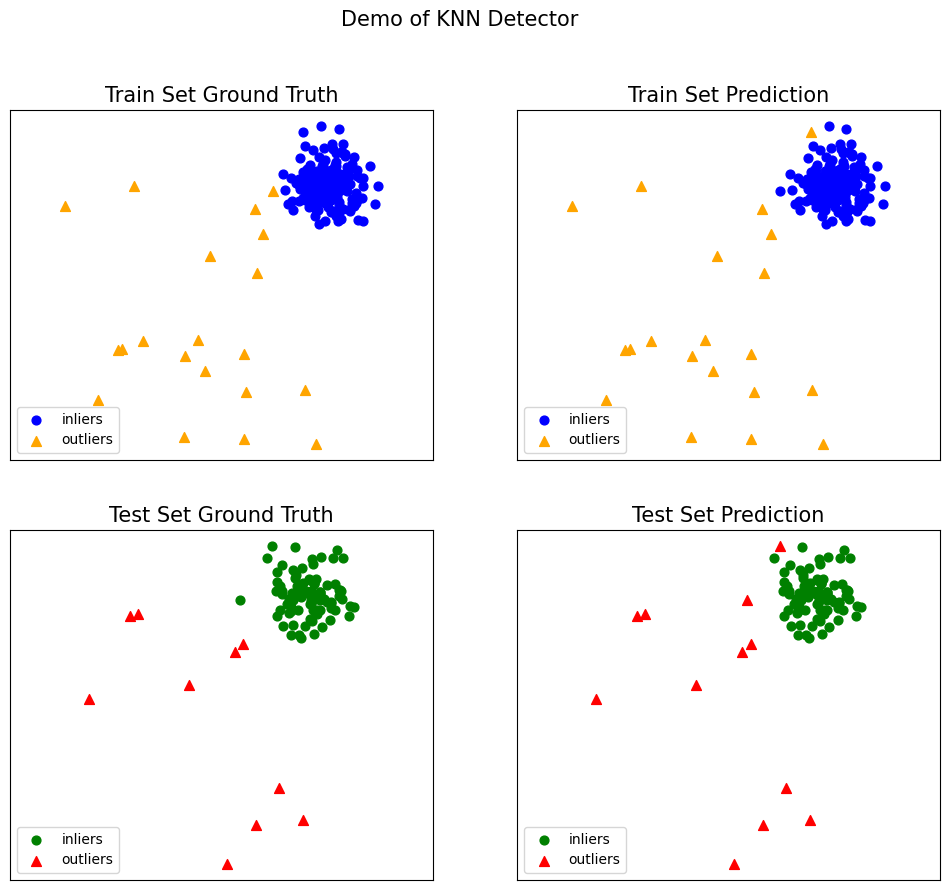

In [3]:
# 4. Visualize the Results
# This function automatically plots the inliers (blue/green) and outliers (orange/red)
# It also draws the decision boundary (the "circle" around the normal data)
visualize(
    clf_name,
    X_train, y_train,
    X_test, y_test,
    y_train_pred,
    y_test_pred,
    show_figure=True,
    save_figure=False
)

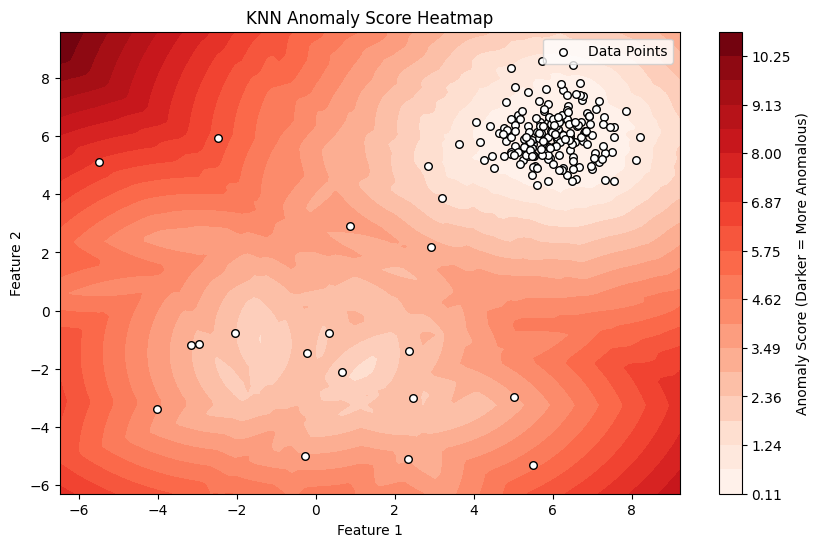

In [4]:
# Create a grid to show anomaly scores across the entire 2D space
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Predict scores for every point on the grid
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
# Plot the anomaly score heat map
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 20), cmap='Reds')
plt.colorbar(label='Anomaly Score (Darker = More Anomalous)')

# Plot the actual data points
plt.scatter(X_train[:, 0], X_train[:, 1], c='white', edgecolors='k', s=30, label='Data Points')

plt.title("KNN Anomaly Score Heatmap")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()